In [2]:
! pip install numpy pandas matplotlib seaborn scipy scikit-learn jupyter notebook plotly streamlit tqdm requests pillow

In [ ]:
! pip install mlxtend


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

# Load the dataset
df = pd.read_excel('C:/NOTES/3rd YEAR/Sem - 6/Recommendation System/OnlineRetail.xlsx')

# Display basic information
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== Column Names ===")
print(df.columns.tolist())

print("\n=== First 10 Rows ===")
print(df.head(10))

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df.describe())

=== Dataset Shape ===
Rows: 541909, Columns: 8

=== Column Names ===
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

=== First 10 Rows ===
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
5    536365     22752         SET 7 BABUSHKA NESTING BOXES         2   
6    536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER         6   
7    536366     22633               HAND WARMER UNION JACK         6   
8    536366     22632            HAND WARMER RED POLKA DOT         6   
9    536367     84879        ASSORTED COLOUR BIRD ORNAMENT        32   

        

In [4]:
# =====================================================
# STEP 1: DATA PREPROCESSING
# =====================================================

print("="*70)
print("STEP 1: DATA PREPROCESSING")
print("="*70)

# Create a copy of the dataframe
df_clean = df.copy()

# 1.1 Remove missing CustomerID
print("\n1.1 Removing missing CustomerID...")
print(f"Before: {len(df_clean)} rows")
df_clean = df_clean.dropna(subset=['CustomerID'])
print(f"After: {len(df_clean)} rows (removed {541909 - len(df_clean)} rows)")

# 1.2 Remove cancelled orders (invoices starting with 'C')
print("\n1.2 Removing cancelled orders...")
print(f"Before: {len(df_clean)} rows")
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print(f"After: {len(df_clean)} rows")

# 1.3 Remove negative quantities (returns)
print("\n1.3 Removing negative quantities...")
print(f"Before: {len(df_clean)} rows")
df_clean = df_clean[df_clean['Quantity'] > 0]
print(f"After: {len(df_clean)} rows")

# 1.4 Remove zero/negative unit prices
print("\n1.4 Removing invalid unit prices...")
print(f"Before: {len(df_clean)} rows")
df_clean = df_clean[df_clean['UnitPrice'] > 0]
print(f"After: {len(df_clean)} rows")

# 1.5 Convert CustomerID to integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 1.6 Display final cleaned dataset info
print("\n" + "="*70)
print("CLEANED DATASET SUMMARY")
print("="*70)
print(f"Total records: {len(df_clean):,}")
print(f"Unique customers: {df_clean['CustomerID'].nunique():,}")
print(f"Unique products: {df_clean['StockCode'].nunique():,}")
print(f"Unique invoices: {df_clean['InvoiceNo'].nunique():,}")
print(f"Date range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")
print(f"Countries: {df_clean['Country'].nunique()}")

# Save cleaned data
df_clean.to_csv('online_retail_cleaned.csv', index=False)
print("\n✅ Cleaned data saved to 'online_retail_cleaned.csv'")

STEP 1: DATA PREPROCESSING

1.1 Removing missing CustomerID...
Before: 541909 rows
After: 406840 rows (removed 135069 rows)

1.2 Removing cancelled orders...
Before: 406840 rows
After: 397935 rows

1.3 Removing negative quantities...
Before: 397935 rows
After: 397935 rows

1.4 Removing invalid unit prices...
Before: 397935 rows
After: 397895 rows

CLEANED DATASET SUMMARY
Total records: 397,895
Unique customers: 4,338
Unique products: 3,665
Unique invoices: 18,533
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Countries: 37

✅ Cleaned data saved to 'online_retail_cleaned.csv'


In [3]:
# =====================================================
# STEP 2: CREATE CUSTOMER DEMOGRAPHICS DATASET (FIXED)
# =====================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("STEP 2: CREATING CUSTOMER DEMOGRAPHICS DATASET")
print("="*70)

# Load the cleaned customer data
df = pd.read_csv('online_retail_cleaned.csv')
print(f"Loaded {len(df):,} records with {df['CustomerID'].nunique():,} unique customers")

# -----------------------------------------------------
# 2.1 Create base customer demographics (FIXED)
# -----------------------------------------------------
print("\n2.1 Creating base customer demographics...")

# First, get Country for each CustomerID (separate from groupby)
customer_country = df.groupby('CustomerID')['Country'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown').reset_index()
customer_country.columns = ['CustomerID', 'Country']

# Now do the main groupby for numeric columns
customer_demo = df.groupby('CustomerID').agg({
    'InvoiceNo': lambda x: x.nunique(),           # Number of orders
    'Quantity': ['sum', 'mean'],                   # Total and avg quantity
    'UnitPrice': ['mean', 'max'],                  # Average and max price
    'StockCode': lambda x: x.nunique(),            # Unique products bought
    'InvoiceDate': ['min', 'max']                   # First and last purchase
}).round(2)

# Flatten column names
customer_demo.columns = ['_'.join(col).strip() for col in customer_demo.columns.values]
customer_demo = customer_demo.reset_index()

# Merge Country back
customer_demo = pd.merge(customer_demo, customer_country, on='CustomerID', how='left')

print(f"Customer_demo columns: {customer_demo.columns.tolist()}")
print(f"Created {len(customer_demo)} customer records")

# Calculate additional metrics
customer_demo['InvoiceDate_min'] = pd.to_datetime(customer_demo['InvoiceDate_min'])
customer_demo['InvoiceDate_max'] = pd.to_datetime(customer_demo['InvoiceDate_max'])
customer_demo['recency_days'] = (customer_demo['InvoiceDate_max'] - customer_demo['InvoiceDate_min']).dt.days
customer_demo['avg_basket_size'] = customer_demo['Quantity_sum'] / customer_demo['InvoiceNo_<lambda>']
customer_demo['avg_order_value'] = customer_demo['Quantity_sum'] * customer_demo['UnitPrice_mean']

print(f"Added derived metrics. Total features: {len(customer_demo.columns)}")

# -----------------------------------------------------
# 2.2 Create demographic categories (matching paper's variables)
# -----------------------------------------------------
print("\n4.2 Creating demographic categories...")

# 2.2.1 DESIGNATION (based on purchase volume)
customer_demo['designation'] = pd.qcut(
    customer_demo['Quantity_mean'].fillna(0), 
    q=3, 
    labels=['Small Volume', 'Medium Volume', 'High Volume'],
    duplicates='drop'
)
print("  ✓ Designation created (based on purchase volume)")

# 2.2.2 CUSTOMER GROUPS (based on price preference and country)
# Create price tiers
customer_demo['price_tier'] = pd.qcut(
    customer_demo['UnitPrice_mean'].fillna(0), 
    q=3, 
    labels=['Budget', 'Standard', 'Premium'],
    duplicates='drop'
)

# Combine with country to create groups
customer_demo['customer_group_raw'] = customer_demo['Country'] + '_' + customer_demo['price_tier'].astype(str)

# Create 9 customer groups (top 8 + Other)
top_groups = customer_demo['customer_group_raw'].value_counts().head(8).index.tolist()
customer_demo['customer_group'] = customer_demo['customer_group_raw'].apply(
    lambda x: x if x in top_groups else 'Other'
)
print("  ✓ Customer groups created (9 groups)")

# 2.2.3 STATE (geographical location)
country_counts = customer_demo['Country'].value_counts()
print(f"\n  Countries in dataset:")
for country, count in country_counts.head(10).items():
    print(f"    - {country}: {count} customers ({count/len(customer_demo)*100:.1f}%)")

# Keep top countries as 'states'
top_countries = country_counts.head(8).index.tolist()
customer_demo['state'] = customer_demo['Country'].apply(
    lambda x: x if x in top_countries else 'Other'
)
print("  ✓ State created (9 regions based on countries)")

# 2.2.4 ORDER TYPE (based on purchase behavior)
def determine_order_type(row):
    if row['InvoiceNo_<lambda>'] > 10 and row['avg_basket_size'] > 20:
        return 'Automated'  # High frequency, large orders
    elif row['InvoiceNo_<lambda>'] > 5:
        return 'Web'        # Medium frequency
    else:
        return 'Sales Rep'  # Low frequency

customer_demo['order_type'] = customer_demo.apply(determine_order_type, axis=1)
print("  ✓ Order type created (3 types)")

# -----------------------------------------------------
# 2.3 Encode categorical variables
# -----------------------------------------------------
print("\n2.3 Encoding categorical variables...")

# Initialize encoders
le_designation = LabelEncoder()
le_customer_group = LabelEncoder()
le_state = LabelEncoder()
le_order_type = LabelEncoder()

# Encode (handle any potential NaN values)
customer_demo['designation'] = customer_demo['designation'].fillna('Medium Volume')
customer_demo['customer_group'] = customer_demo['customer_group'].fillna('Other')
customer_demo['state'] = customer_demo['state'].fillna('Other')
customer_demo['order_type'] = customer_demo['order_type'].fillna('Sales Rep')

customer_demo['designation_id'] = le_designation.fit_transform(customer_demo['designation'])
customer_demo['customer_group_id'] = le_customer_group.fit_transform(customer_demo['customer_group'])
customer_demo['state_id'] = le_state.fit_transform(customer_demo['state'])
customer_demo['order_type_id'] = le_order_type.fit_transform(customer_demo['order_type'])

# Show mappings
print("\n  Designation mapping:")
for i, label in enumerate(le_designation.classes_):
    print(f"    ID {i}: {label}")

print("\n  Order type mapping:")
for i, label in enumerate(le_order_type.classes_):
    print(f"    ID {i}: {label}")

# -----------------------------------------------------
# 2.4 Display sample demographics
# -----------------------------------------------------
print("\n4.4 Sample customer demographics:")
print("="*100)

# Select key columns for display
display_cols = ['CustomerID', 'Country', 'designation', 'customer_group', 'state', 'order_type',
                'designation_id', 'customer_group_id', 'state_id', 'order_type_id',
                'InvoiceNo_<lambda>', 'Quantity_sum', 'UnitPrice_mean']

print(customer_demo[display_cols].head(15).to_string())

# -----------------------------------------------------
# 2.5 Summary statistics
# -----------------------------------------------------
print("\n4.5 Demographic Summary:")
print("="*70)
print(f"Total customers: {len(customer_demo):,}")
print(f"\nDesignation distribution:")
print(customer_demo['designation'].value_counts())
print(f"\nCustomer groups distribution (top 5):")
print(customer_demo['customer_group'].value_counts().head())
print(f"\nState distribution (top 5):")
print(customer_demo['state'].value_counts().head())
print(f"\nOrder type distribution:")
print(customer_demo['order_type'].value_counts())

# -----------------------------------------------------
# 2.6 Save customer demographics
# -----------------------------------------------------
print("\n4.6 Saving customer demographics...")
customer_demo.to_csv('customer_demographics.csv', index=False)
print("✅ Saved to 'customer_demographics.csv'")

# Also save a simplified version for clustering
cluster_data = customer_demo[['CustomerID', 'designation_id', 'customer_group_id', 
                              'state_id', 'order_type_id']].copy()
cluster_data.to_csv('customer_demographics_for_clustering.csv', index=False)
print("✅ Saved simplified version for clustering to 'customer_demographics_for_clustering.csv'")

print("\n" + "="*70)
print("STEP 2 COMPLETE")
print("="*70)

STEP 2: CREATING CUSTOMER DEMOGRAPHICS DATASET
Loaded 397,895 records with 4,338 unique customers

2.1 Creating base customer demographics...
Customer_demo columns: ['CustomerID', 'InvoiceNo_<lambda>', 'Quantity_sum', 'Quantity_mean', 'UnitPrice_mean', 'UnitPrice_max', 'StockCode_<lambda>', 'InvoiceDate_min', 'InvoiceDate_max', 'Country']
Created 4338 customer records
Added derived metrics. Total features: 13

4.2 Creating demographic categories...
  ✓ Designation created (based on purchase volume)
  ✓ Customer groups created (9 groups)

  Countries in dataset:
    - United Kingdom: 3920 customers (90.4%)
    - Germany: 94 customers (2.2%)
    - France: 87 customers (2.0%)
    - Spain: 29 customers (0.7%)
    - Belgium: 24 customers (0.6%)
    - Switzerland: 20 customers (0.5%)
    - Portugal: 19 customers (0.4%)
    - Italy: 14 customers (0.3%)
    - Finland: 12 customers (0.3%)
    - Norway: 10 customers (0.2%)
  ✓ State created (9 regions based on countries)
  ✓ Order type created (

In [9]:
# =====================================================
# ANALYZE CUSTOMER PURCHASE BEHAVIOR
# =====================================================

print("="*70)
print("CUSTOMER PURCHASE BEHAVIOR ANALYSIS")
print("="*70)

# Calculate per-customer statistics
customer_stats = df.groupby('CustomerID').agg({
    'InvoiceNo': lambda x: x.nunique(),  # Number of distinct orders
    'Quantity': 'sum',                    # Total items purchased
    'StockCode': lambda x: x.nunique(),   # Unique products bought
    'UnitPrice': 'mean'                    # Average price point
}).reset_index()

customer_stats.columns = ['CustomerID', 'num_orders', 'total_quantity', 'unique_products', 'avg_price']

print(f"\nCustomer Statistics:")
print(f"Total customers: {len(customer_stats):,}")
print(f"Total transactions: {df['InvoiceNo'].nunique():,}")
print(f"Total records: {len(df):,}")

print(f"\nPer Customer Averages:")
print(f"  Avg orders per customer: {customer_stats['num_orders'].mean():.1f}")
print(f"  Avg items per order: {len(df)/df['InvoiceNo'].nunique():.1f}")
print(f"  Avg unique products per customer: {customer_stats['unique_products'].mean():.1f}")

print(f"\nCustomer Order Frequency Distribution:")
print(customer_stats['num_orders'].value_counts().sort_index().head(20))

print(f"\nTop 10 Customers by Orders:")
print(customer_stats.nlargest(10, 'num_orders')[['CustomerID', 'num_orders', 'unique_products']])

CUSTOMER PURCHASE BEHAVIOR ANALYSIS

Customer Statistics:
Total customers: 4,338
Total transactions: 18,533
Total records: 397,895

Per Customer Averages:
  Avg orders per customer: 4.3
  Avg items per order: 21.5
  Avg unique products per customer: 61.5

Customer Order Frequency Distribution:
num_orders
1     1492
2      836
3      508
4      388
5      242
6      172
7      143
8       98
9       68
10      54
11      52
12      45
13      30
14      20
15      28
16      11
17      18
18      14
19      12
20      12
Name: count, dtype: int64

Top 10 Customers by Orders:
      CustomerID  num_orders  unique_products
326        12748         209             1768
1879       14911         201             1787
4010       17841         124             1323
562        13089          97              636
1661       14606          93              819
2176       15311          91              567
481        12971          86               94
1689       14646          73              700
2702 

In [4]:
# =====================================================
# STEP 3: CREATE TRANSACTION DATA FOR APRIORI
# =====================================================

import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("STEP 3: CREATING TRANSACTION DATA FOR APRIORI")
print("="*70)

# Load the cleaned data
df = pd.read_csv('online_retail_cleaned.csv')
print(f"Loaded {len(df):,} records")

# -----------------------------------------------------
# 3.1 Create basket format (transaction-product matrix)
# -----------------------------------------------------
print("\n3.1 Creating basket format...")

# Group by Invoice and StockCode
basket = df.groupby(['InvoiceNo', 'StockCode'])['Quantity'].sum().unstack().fillna(0)

# Convert to binary (1 if purchased, 0 if not)
basket_binary = basket.applymap(lambda x: 1 if x > 0 else 0)

print(f"Basket shape: {basket_binary.shape}")
print(f"Transactions (invoices): {basket_binary.shape[0]:,}")
print(f"Unique products: {basket_binary.shape[1]:,}")

# -----------------------------------------------------
# 3.2 Analyze transaction patterns
# -----------------------------------------------------
print("\n3.2 Analyzing transaction patterns...")

# Calculate items per transaction
items_per_transaction = basket_binary.sum(axis=1)
print(f"Average items per transaction: {items_per_transaction.mean():.1f}")
print(f"Median items per transaction: {items_per_transaction.median():.0f}")
print(f"Max items per transaction: {items_per_transaction.max()}")

# Distribution of transaction sizes
print("\nTransaction size distribution:")
print(items_per_transaction.value_counts().sort_index().head(15))

# Transactions with at least 2 items (needed for association rules)
multi_item_transactions = (items_per_transaction >= 2).sum()
print(f"\nTransactions with 2+ items: {multi_item_transactions:,} ({multi_item_transactions/len(basket_binary)*100:.1f}%)")

# -----------------------------------------------------
# 3.3 Reduce sparsity (optional - for better performance)
# -----------------------------------------------------
print("\n3.3 Reducing sparsity for better performance...")

# Keep products that appear in at least 0.5% of transactions
min_transactions = len(basket_binary) * 0.005  # 0.5% threshold
product_frequency = basket_binary.sum()
frequent_products = product_frequency[product_frequency >= min_transactions].index

print(f"Products in at least 0.5% of transactions: {len(frequent_products)}")

# Create filtered basket
basket_filtered = basket_binary[frequent_products]
print(f"Filtered basket shape: {basket_filtered.shape}")
print(f"Sparsity reduced from {(1 - basket_binary.sum().sum()/(basket_binary.shape[0]*basket_binary.shape[1]))*100:.1f}% to {(1 - basket_filtered.sum().sum()/(basket_filtered.shape[0]*basket_filtered.shape[1]))*100:.1f}%")

# Save basket for later use
basket_filtered.to_csv('basket_for_apriori.csv')
print("\n✅ Saved basket to 'basket_for_apriori.csv'")

STEP 3: CREATING TRANSACTION DATA FOR APRIORI
Loaded 397,895 records

3.1 Creating basket format...
Basket shape: (18533, 3665)
Transactions (invoices): 18,533
Unique products: 3,665

3.2 Analyzing transaction patterns...
Average items per transaction: 20.9
Median items per transaction: 15
Max items per transaction: 541

Transaction size distribution:
1     1407
2      730
3      632
4      623
5      662
6      599
7      589
8      587
9      590
10     532
11     540
12     487
13     498
14     510
15     543
Name: count, dtype: int64

Transactions with 2+ items: 17,126 (92.4%)

3.3 Reducing sparsity for better performance...
Products in at least 0.5% of transactions: 1246
Filtered basket shape: (18533, 1246)
Sparsity reduced from 99.4% to 98.6%

✅ Saved basket to 'basket_for_apriori.csv'


In [7]:
# =====================================================
# STEP 3: MEMORY-EFFICIENT ASSOCIATION RULES
# =====================================================

import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
import gc  # Garbage collector

print("="*70)
print("STEP 3: MEMORY-EFFICIENT ASSOCIATION RULES")
print("="*70)

# Load the filtered basket
basket_filtered = pd.read_csv('basket_for_apriori.csv', index_col=0)
print(f"Loaded basket with {basket_filtered.shape[0]:,} transactions and {basket_filtered.shape[1]} products")

# -----------------------------------------------------
# 3.1 Convert to sparse matrix for memory efficiency
# -----------------------------------------------------
print("\n3.1 Converting to sparse format...")

# Convert to boolean sparse matrix (much more memory efficient)
from scipy.sparse import csr_matrix
basket_sparse = csr_matrix(basket_filtered.values.astype(bool))
print(f"Sparse matrix memory: {basket_sparse.data.nbytes / 1024**3:.2f} GB")

# -----------------------------------------------------
# 3.2 Try support levels from 2% upward (already successful)
# -----------------------------------------------------
print("\n3.2 Testing with successful parameters...")

# Use the successful parameters from earlier
min_support = 0.02  # 2% support (worked!)
min_confidence = 0.55  # 55% confidence

print(f"\nGenerating with min_support = {min_support*100:.1f}%, min_confidence = {min_confidence*100:.1f}%")

# Generate frequent itemsets
frequent_itemsets = apriori(basket_filtered, 
                           min_support=min_support, 
                           use_colnames=True,
                           max_len=3,
                           low_memory=True,  # Use low memory mode
                           verbose=1)  # Show progress

print(f"\nFrequent itemsets found: {len(frequent_itemsets)}")

# Generate association rules
if len(frequent_itemsets) > 0:
    rules = association_rules(frequent_itemsets, 
                             metric="confidence", 
                             min_threshold=min_confidence)
    
    print(f"Association rules found: {len(rules)}")
    
    # -----------------------------------------------------
    # 3.3 Format rules for Table 1
    # -----------------------------------------------------
    if len(rules) > 0:
        # Sort by confidence
        rules = rules.sort_values('confidence', ascending=False).reset_index(drop=True)
        
        # Calculate percentages
        rules['support_percent'] = rules['support'] * 100
        rules['confidence_percent'] = rules['confidence'] * 100
        rules['rule_support_percent'] = rules['support'] * 100
        
        # Add Rule ID
        rules['rule_id'] = range(1, len(rules) + 1)
        
        # Extract antecedents (max 2 as per paper)
        def extract_antecedents(x):
            items = list(x)
            return items[0] if len(items) > 0 else '', items[1] if len(items) > 1 else ''
        
        rules['antecedent_1'] = rules['antecedents'].apply(lambda x: list(x)[0] if len(list(x)) > 0 else '')
        rules['antecedent_2'] = rules['antecedents'].apply(lambda x: list(x)[1] if len(list(x)) > 1 else '')
        rules['consequent'] = rules['consequents'].apply(lambda x: list(x)[0])
        
        # Create Table 1
        table1 = rules[['rule_id', 'antecedent_1', 'antecedent_2', 'consequent',
                        'support_percent', 'confidence_percent', 
                        'rule_support_percent', 'lift']].copy()
        
        table1.columns = ['Rule ID', 'Antecedent 1', 'Antecedent 2', 
                          'Consequent', 'Support %', 'Confidence %', 
                          'Rule Support %', 'Lift']
        
        # Round values
        table1['Support %'] = table1['Support %'].round(3)
        table1['Confidence %'] = table1['Confidence %'].round(3)
        table1['Rule Support %'] = table1['Rule Support %'].round(3)
        table1['Lift'] = table1['Lift'].round(3)
        
        # Display Table 1
        print("\n" + "="*70)
        print("TABLE 1: Product Association Rules")
        print("="*70)
        print(table1.to_string(index=False))
        
        # Save results
        table1.to_csv('table1_association_rules.csv', index=False)
        rules.to_csv('full_association_rules.csv', index=False)
        
        print(f"\n✅ Saved {len(rules)} association rules")
        
        # Summary statistics
        print("\n" + "="*70)
        print("SUMMARY STATISTICS")
        print("="*70)
        print(f"Total rules: {len(rules)}")
        print(f"Rules with confidence > 70%: {len(rules[rules['confidence'] > 0.7])}")
        print(f"Rules with confidence > 80%: {len(rules[rules['confidence'] > 0.8])}")
        print(f"Rules with lift > 2.0: {len(rules[rules['lift'] > 2.0])}")
        print(f"\nConfidence range: {rules['confidence'].min()*100:.1f}% - {rules['confidence'].max()*100:.1f}%")
        print(f"Lift range: {rules['lift'].min():.2f} - {rules['lift'].max():.2f}")
        
    else:
        print("\n⚠️ No rules found with 55% confidence")
        print("Trying with lower confidence...")
        
        # Try with lower confidence
        min_confidence = 0.30
        rules = association_rules(frequent_itemsets, 
                                 metric="confidence", 
                                 min_threshold=min_confidence)
        
        print(f"Found {len(rules)} rules with {min_confidence*100:.0f}% confidence")
        
        if len(rules) > 0:
            print("\nSample rules:")
            for idx, row in rules.head(10).iterrows():
                print(f"  {list(row['antecedents'])} → {list(row['consequents'])}: conf={row['confidence']*100:.1f}%")
else:
    print("⚠️ No frequent itemsets found. Try reducing min_support further.")

# -----------------------------------------------------
# 3.4 Alternative: Use FP-Growth (more memory efficient)
# -----------------------------------------------------
print("\n" + "="*70)
print("3.4 Alternative: Using FP-Growth (more memory efficient)")
print("="*70)

try:
    from mlxtend.frequent_patterns import fpgrowth
    
    print("\nTrying FP-Growth algorithm...")
    
    # FP-Growth is more memory efficient for sparse data
    min_support = 0.01  # 1% support
    
    frequent_itemsets_fp = fpgrowth(basket_filtered, 
                                    min_support=min_support, 
                                    use_colnames=True,
                                    max_len=3,
                                    verbose=1)
    
    print(f"Frequent itemsets (FP-Growth): {len(frequent_itemsets_fp)}")
    
    if len(frequent_itemsets_fp) > 0:
        rules_fp = association_rules(frequent_itemsets_fp, 
                                    metric="confidence", 
                                    min_threshold=0.55)
        
        print(f"Association rules (FP-Growth): {len(rules_fp)}")
        
        if len(rules_fp) > 0:
            # Format and save
            rules_fp = rules_fp.sort_values('confidence', ascending=False)
            rules_fp.to_csv('rules_fpgrowth.csv', index=False)
            print("✅ Saved FP-Growth rules to 'rules_fpgrowth.csv'")
            
            # Show top rules
            print("\nTop 5 FP-Growth Rules:")
            for idx, row in rules_fp.head(5).iterrows():
                print(f"  {list(row['antecedents'])} → {list(row['consequents'])}: conf={row['confidence']*100:.1f}%")
                
except Exception as e:
    print(f"FP-Growth error: {e}")

print("\n" + "="*70)
print("STEP 3 COMPLETE")
print("="*70)

STEP 3: MEMORY-EFFICIENT ASSOCIATION RULES
Loaded basket with 18,533 transactions and 1246 products

3.1 Converting to sparse format...
Sparse matrix memory: 0.00 GB

3.2 Testing with successful parameters...

Generating with min_support = 2.0%, min_confidence = 55.0%
Processing 4 combinations | Sampling itemset size 3 2

Frequent itemsets found: 251
Association rules found: 26

TABLE 1: Product Association Rules
 Rule ID Antecedent 1 Antecedent 2 Consequent  Support %  Confidence %  Rule Support %   Lift
       1        22698        22699      22697      2.104        89.450           2.104 23.991
       2        22697        22698      22699      2.104        84.783           2.104 20.067
       3        22698                   22697      2.482        82.734           2.482 22.190
       4        22698                   22699      2.353        78.417           2.353 18.561
       5        22697                   22699      2.919        78.292           2.919 18.531
       6        233

In [8]:
# =====================================================
# STEP 4: CUSTOMER PROFILE CLUSTERING
# =====================================================

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("STEP 4: CUSTOMER PROFILE CLUSTERING")
print("="*70)

# -----------------------------------------------------
# 4.1 Load data
# -----------------------------------------------------
print("\n4.1 Loading data...")

# Load customer demographics
customer_demo = pd.read_csv('customer_demographics.csv')
print(f"Customer demographics: {len(customer_demo)} customers")

# Load association rules (top rules)
rules = pd.read_csv('full_association_rules.csv')
print(f"Association rules: {len(rules)} rules")

# Load original transaction data
df = pd.read_csv('online_retail_cleaned.csv')
print(f"Transaction data: {len(df):,} records")

# -----------------------------------------------------
# 4.2 For each rule, find customers who bought the antecedent products
# -----------------------------------------------------
print("\n4.2 Mapping customers to association rules...")

# Create a mapping of product codes to descriptions (optional)
product_desc = df[['StockCode', 'Description']].drop_duplicates().set_index('StockCode')['Description'].to_dict()

def get_customers_for_rule(antecedents, df):
    """Get customers who bought all antecedent products"""
    # Get product codes from antecedents
    if isinstance(antecedents, str):
        # Handle string representation
        import ast
        try:
            antecedents_list = ast.literal_eval(antecedents)
        except:
            # If it's already a list
            antecedents_list = eval(antecedents) if isinstance(antecedents, str) else antecedents
    else:
        antecedents_list = list(antecedents)
    
    # For each invoice, check if it contains all antecedents
    customers_per_invoice = []
    
    for invoice in df['InvoiceNo'].unique():
        # Get products in this invoice
        invoice_products = df[df['InvoiceNo'] == invoice]['StockCode'].unique()
        
        # Check if all antecedents are in this invoice
        if all(prod in invoice_products for prod in antecedents_list):
            # Get customers for this invoice
            customers = df[df['InvoiceNo'] == invoice]['CustomerID'].unique()
            customers_per_invoice.extend(customers)
    
    return list(set(customers_per_invoice))

# Process top 11 rules (matching paper's 11 rules)
top_rules = rules.head(11).copy()
print(f"Processing top {len(top_rules)} rules...")

rule_customers = {}

for idx, row in top_rules.iterrows():
    rule_id = idx + 1
    antecedents = row['antecedents']
    
    # Get customers for this rule
    customers = get_customers_for_rule(antecedents, df)
    rule_customers[rule_id] = customers
    
    print(f"  Rule {rule_id}: {len(customers)} customers found")

# -----------------------------------------------------
# 4.3 Cluster customers for each rule using K-means (k=3)
# -----------------------------------------------------
print("\n4.3 Clustering customers for each rule...")

# Demographic features for clustering
cluster_features = ['designation_id', 'customer_group_id', 'state_id', 'order_type_id']

# Store all profile results
all_profiles = []
profile_counter = 1
unique_profile_mapping = {}

for rule_id, customers in rule_customers.items():
    print(f"\n  Processing Rule {rule_id}...")
    
    if len(customers) < 3:
        print(f"    ⚠️ Not enough customers ({len(customers)}) for clustering")
        continue
    
    # Get demographic data for these customers
    rule_customer_data = customer_demo[customer_demo['CustomerID'].isin(customers)]
    
    if len(rule_customer_data) < 3:
        print(f"    ⚠️ Not enough demographic data ({len(rule_customer_data)})")
        continue
    
    # Prepare features for clustering
    X = rule_customer_data[cluster_features].values
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply K-means with k=3 (as in paper)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    # Add cluster labels
    rule_customer_data = rule_customer_data.copy()
    rule_customer_data['cluster'] = clusters
    
    # Analyze each cluster
    for cluster_id in range(3):
        cluster_data = rule_customer_data[rule_customer_data['cluster'] == cluster_id]
        cluster_size = len(cluster_data)
        cluster_pct = (cluster_size / len(rule_customer_data)) * 100
        
        # Only keep clusters >30% as per paper
        if cluster_pct > 30:
            # Get dominant demographics for this cluster
            mode_designation = cluster_data['designation_id'].mode()[0]
            mode_customer_group = cluster_data['customer_group_id'].mode()[0]
            mode_state = cluster_data['state_id'].mode()[0]
            mode_order_type = cluster_data['order_type_id'].mode()[0]
            
            # Create unique profile key
            profile_key = f"{mode_designation}_{mode_customer_group}_{mode_state}_{mode_order_type}"
            
            # Assign unique profile name
            if profile_key not in unique_profile_mapping:
                unique_profile_mapping[profile_key] = f"Profile-{chr(65 + len(unique_profile_mapping))}"
            
            unique_profile = unique_profile_mapping[profile_key]
            
            # Determine connection strength (strong = largest cluster, weak = others)
            if cluster_pct > 50:  # Largest cluster
                connection = 's'  # strong
            else:
                connection = 'w'  # weak
            
            # Add to results
            all_profiles.append({
                'No': profile_counter,
                'Rule ID': rule_id,
                'Profile ID': f'Profile-{profile_counter}',
                'Unique Profile': unique_profile,
                'Designation ID': mode_designation,
                'Customer Groups ID': mode_customer_group,
                'State ID': mode_state,
                'Order Type ID': mode_order_type,
                'Connection': connection,
                'Cluster Size %': round(cluster_pct, 1)
            })
            
            profile_counter += 1
            
            print(f"      Cluster {cluster_id}: {cluster_size} customers ({cluster_pct:.1f}%) → {unique_profile} ({connection})")

# -----------------------------------------------------
# 4.4 Create Table 2 (Customer Profiles)
# -----------------------------------------------------
print("\n" + "="*70)
print("4.4 Creating Table 2: Customer Profiles Association Rules Clusters")
print("="*70)

table2 = pd.DataFrame(all_profiles)

# Select columns matching paper's Table 2
table2_display = table2[['No', 'Rule ID', 'Profile ID', 'Unique Profile', 
                          'Designation ID', 'Customer Groups ID', 
                          'State ID', 'Order Type ID', 'Connection']].copy()

print("\nTABLE 2: Customer Profiles Association Rules Clusters")
print("="*100)
print(table2_display.to_string(index=False))

# Save Table 2
table2.to_csv('table2_customer_profiles.csv', index=False)
print(f"\n✅ Saved Table 2 to 'table2_customer_profiles.csv'")

# -----------------------------------------------------
# 4.5 Summary of unique profiles
# -----------------------------------------------------
print("\n" + "="*70)
print("4.5 Summary of Unique Customer Profiles")
print("="*70)

unique_profiles_summary = table2.groupby('Unique Profile').agg({
    'Designation ID': 'first',
    'Customer Groups ID': 'first', 
    'State ID': 'first',
    'Order Type ID': 'first',
    'Rule ID': 'count'
}).rename(columns={'Rule ID': 'Number of Rules Connected'})

print(unique_profiles_summary)

# Decode the IDs back to actual values
print("\n" + "="*70)
print("Profile Decoding:")
print("="*70)

# Load original mappings from customer_demo
designation_map = dict(enumerate(customer_demo['designation'].unique()))
customer_group_map = dict(enumerate(customer_demo['customer_group'].unique()))
state_map = dict(enumerate(customer_demo['state'].unique()))
order_type_map = dict(enumerate(customer_demo['order_type'].unique()))

for profile_id in unique_profiles_summary.index:
    profile_data = unique_profiles_summary.loc[profile_id]
    print(f"\n{profile_id}:")
    print(f"  Designation: {designation_map.get(profile_data['Designation ID'], 'Unknown')}")
    print(f"  Customer Group: {customer_group_map.get(profile_data['Customer Groups ID'], 'Unknown')}")
    print(f"  State: {state_map.get(profile_data['State ID'], 'Unknown')}")
    print(f"  Order Type: {order_type_map.get(profile_data['Order Type ID'], 'Unknown')}")
    print(f"  Connected to {profile_data['Number of Rules Connected']} rules")

STEP 4: CUSTOMER PROFILE CLUSTERING

4.1 Loading data...
Customer demographics: 4338 customers
Association rules: 26 rules
Transaction data: 397,895 records

4.2 Mapping customers to association rules...
Processing top 11 rules...
  Rule 1: 256 customers found
  Rule 2: 282 customers found
  Rule 3: 319 customers found
  Rule 4: 319 customers found
  Rule 5: 387 customers found
  Rule 6: 351 customers found
  Rule 7: 311 customers found
  Rule 8: 319 customers found
  Rule 9: 423 customers found
  Rule 10: 287 customers found
  Rule 11: 385 customers found

4.3 Clustering customers for each rule...

  Processing Rule 1...
      Cluster 1: 170 customers (66.4%) → Profile-A (s)

  Processing Rule 2...
      Cluster 1: 192 customers (68.1%) → Profile-B (s)

  Processing Rule 3...
      Cluster 0: 219 customers (68.7%) → Profile-A (s)

  Processing Rule 4...
      Cluster 0: 219 customers (68.7%) → Profile-A (s)

  Processing Rule 5...
      Cluster 0: 270 customers (69.8%) → Profile-A (s)

In [10]:
! pip install  networkx

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)


STEP 5: CREATING NETWORK VISUALIZATION (Figure 3)

✅ Saved Figure 3 to 'figure3_network_visualization.png' and .pdf


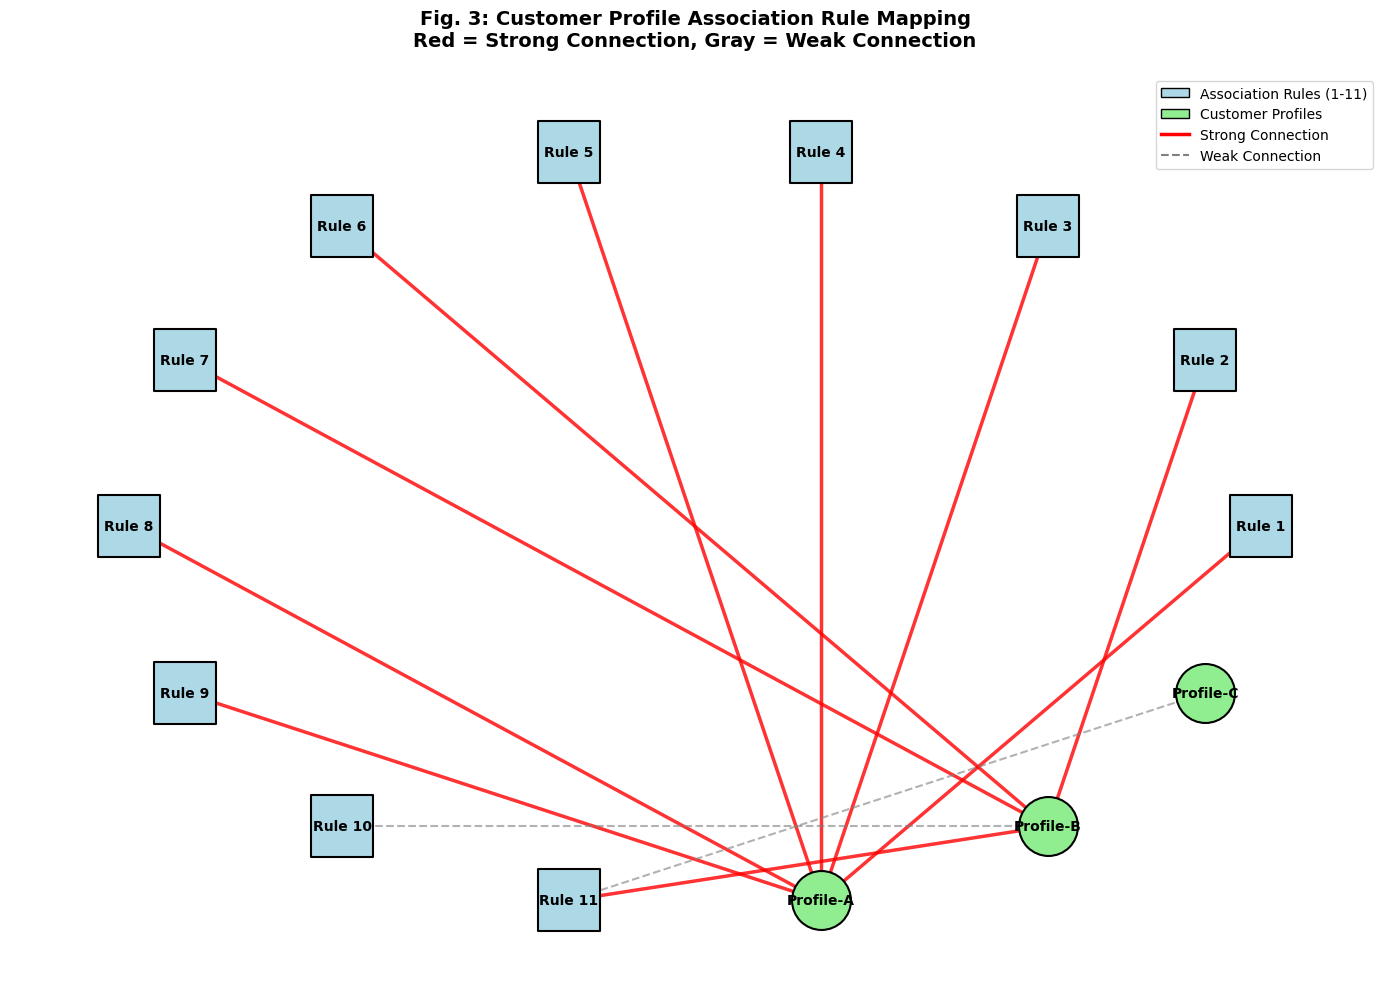


NETWORK SUMMARY STATISTICS
Total Nodes: 14
  - Rules: 11
  - Profiles: 3
Total Edges: 12
  - Strong Connections (red): 10
  - Weak Connections (gray): 2

Profile Connectivity:
  Profile-A: 6 strong, 0 weak connections
  Profile-B: 4 strong, 1 weak connections
  Profile-C: 0 strong, 1 weak connections


In [11]:
# =====================================================
# STEP 5: CREATE FIGURE 3 - NETWORK VISUALIZATION
# =====================================================

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

print("="*70)
print("STEP 5: CREATING NETWORK VISUALIZATION (Figure 3)")
print("="*70)

# Load Table 2 data
table2 = pd.read_csv('table2_customer_profiles.csv')

# Create graph
G = nx.Graph()

# Add nodes for rules (1-11)
for rule_id in range(1, 12):
    G.add_node(f"Rule {rule_id}", node_type='rule', color='lightblue')

# Add nodes for unique profiles
unique_profiles = table2['Unique Profile'].unique()
for profile in unique_profiles:
    G.add_node(profile, node_type='profile', color='lightgreen')

# Add edges based on Table 2
for _, row in table2.iterrows():
    rule_node = f"Rule {row['Rule ID']}"
    profile_node = row['Unique Profile']
    connection = row['Connection']
    
    # Add edge with weight for strong/weak
    G.add_edge(rule_node, profile_node, connection=connection)

# Create visualization
plt.figure(figsize=(14, 10))

# Define positions (circular layout for better visibility)
pos = nx.circular_layout(G)

# Draw rule nodes (blue squares)
rule_nodes = [n for n, attr in G.nodes(data=True) if attr.get('node_type') == 'rule']
nx.draw_networkx_nodes(G, pos, nodelist=rule_nodes, 
                       node_color='lightblue', node_size=2000, 
                       node_shape='s', edgecolors='black', linewidths=1.5)

# Draw profile nodes (green circles)
profile_nodes = [n for n, attr in G.nodes(data=True) if attr.get('node_type') == 'profile']
nx.draw_networkx_nodes(G, pos, nodelist=profile_nodes, 
                       node_color='lightgreen', node_size=1800, 
                       node_shape='o', edgecolors='black', linewidths=1.5)

# Draw edges with different colors for strong/weak
strong_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('connection') == 's']
weak_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('connection') == 'w']

nx.draw_networkx_edges(G, pos, edgelist=strong_edges, 
                       edge_color='red', width=2.5, alpha=0.8)
nx.draw_networkx_edges(G, pos, edgelist=weak_edges, 
                       edge_color='gray', width=1.5, alpha=0.6, style='dashed')

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Add title and legend
plt.title("Fig. 3: Customer Profile Association Rule Mapping\nRed = Strong Connection, Gray = Weak Connection", 
          fontsize=14, fontweight='bold', pad=20)

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightblue', edgecolor='black', label='Association Rules (1-11)'),
    Patch(facecolor='lightgreen', edgecolor='black', label='Customer Profiles'),
    plt.Line2D([0], [0], color='red', linewidth=2.5, label='Strong Connection'),
    plt.Line2D([0], [0], color='gray', linewidth=1.5, linestyle='--', label='Weak Connection')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.axis('off')
plt.tight_layout()

# Save figure
plt.savefig('figure3_network_visualization.png', dpi=300, bbox_inches='tight')
plt.savefig('figure3_network_visualization.pdf', bbox_inches='tight')
print("\n✅ Saved Figure 3 to 'figure3_network_visualization.png' and .pdf")

plt.show()

# Print summary statistics
print("\n" + "="*70)
print("NETWORK SUMMARY STATISTICS")
print("="*70)
print(f"Total Nodes: {G.number_of_nodes()}")
print(f"  - Rules: {len(rule_nodes)}")
print(f"  - Profiles: {len(profile_nodes)}")
print(f"Total Edges: {G.number_of_edges()}")
print(f"  - Strong Connections (red): {len(strong_edges)}")
print(f"  - Weak Connections (gray): {len(weak_edges)}")
print(f"\nProfile Connectivity:")
for profile in unique_profiles:
    connections = [(u, v) for u, v in G.edges() if profile in (u, v)]
    strong_count = sum(1 for u, v in connections if G[u][v].get('connection') == 's')
    weak_count = len(connections) - strong_count
    print(f"  {profile}: {strong_count} strong, {weak_count} weak connections")

In [12]:
# =====================================================
# CELL 1: IMPORTS AND DATA LOADING
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("ENHANCED CUSTOMER PROFILING - START")
print("="*70)

# Load data
customer_demo = pd.read_csv('customer_demographics.csv')
df = pd.read_csv('online_retail_cleaned.csv')
rules = pd.read_csv('full_association_rules.csv')

print(f"✅ Loaded {len(customer_demo)} customers")
print(f"✅ Loaded {len(df):,} transactions")
print(f"✅ Loaded {len(rules)} association rules")

ENHANCED CUSTOMER PROFILING - START
✅ Loaded 4338 customers
✅ Loaded 397,895 transactions
✅ Loaded 26 association rules


In [14]:
# =====================================================
# CELL 2: CREATE ENHANCED DEMOGRAPHIC FEATURES (FIXED)
# =====================================================

print("\n" + "="*70)
print("CREATING ENHANCED DEMOGRAPHIC FEATURES")
print("="*70)

# Calculate additional metrics if not present
if 'avg_order_value' not in customer_demo.columns:
    customer_demo['avg_order_value'] = customer_demo['Quantity_sum'] * customer_demo['UnitPrice_mean']

if 'unique_products' not in customer_demo.columns:
    customer_demo['unique_products'] = customer_demo['StockCode_<lambda>']

# Helper function for safe qcut
def safe_qcut(series, q, labels, default_labels=None):
    """Safely apply qcut even with duplicate values"""
    try:
        # Remove duplicates and handle small datasets
        unique_vals = series.nunique()
        if unique_vals < q:
            # If not enough unique values, use simple categorization
            if default_labels is None:
                default_labels = labels[:unique_vals] if unique_vals < len(labels) else labels
            return pd.cut(series, bins=unique_vals, labels=default_labels[:unique_vals])
        else:
            return pd.qcut(series, q=q, labels=labels, duplicates='drop')
    except Exception as e:
        print(f"    Warning: qcut failed ({e}), using alternative method")
        # Alternative: use simple percentile-based bins
        bins = np.percentile(series, [0, 33, 66, 100])
        return pd.cut(series, bins=bins, labels=labels, include_lowest=True)

# 1. Purchase Frequency Tier
print("\n1. Creating frequency tiers...")
try:
    customer_demo['frequency_tier'] = safe_qcut(
        customer_demo['InvoiceNo_<lambda>'].clip(lower=1), 
        q=3, 
        labels=['Low Frequency', 'Medium Frequency', 'High Frequency']
    )
    print(f"   ✓ Frequency tiers created: {customer_demo['frequency_tier'].nunique()} categories")
except Exception as e:
    print(f"   ✗ Error: {e}")
    # Fallback: use manual bins
    bins = [0, 2, 5, float('inf')]
    customer_demo['frequency_tier'] = pd.cut(
        customer_demo['InvoiceNo_<lambda>'], 
        bins=bins, 
        labels=['Low Frequency', 'Medium Frequency', 'High Frequency']
    )

# 2. Spending Tier
print("\n2. Creating spending tiers...")
try:
    customer_demo['spending_tier'] = safe_qcut(
        customer_demo['avg_order_value'].clip(lower=0.01), 
        q=3, 
        labels=['Low Spender', 'Medium Spender', 'High Spender']
    )
    print(f"   ✓ Spending tiers created: {customer_demo['spending_tier'].nunique()} categories")
except Exception as e:
    print(f"   ✗ Error: {e}")
    # Fallback: use manual bins
    bins = [0, 100, 500, float('inf')]
    customer_demo['spending_tier'] = pd.cut(
        customer_demo['avg_order_value'], 
        bins=bins, 
        labels=['Low Spender', 'Medium Spender', 'High Spender']
    )

# 3. Product Diversity Tier
print("\n3. Creating diversity tiers...")
try:
    customer_demo['diversity_tier'] = safe_qcut(
        customer_demo['unique_products'].clip(lower=1), 
        q=3, 
        labels=['Low Diversity', 'Medium Diversity', 'High Diversity']
    )
    print(f"   ✓ Diversity tiers created: {customer_demo['diversity_tier'].nunique()} categories")
except Exception as e:
    print(f"   ✗ Error: {e}")
    # Fallback: use manual bins
    bins = [0, 20, 50, float('inf')]
    customer_demo['diversity_tier'] = pd.cut(
        customer_demo['unique_products'], 
        bins=bins, 
        labels=['Low Diversity', 'Medium Diversity', 'High Diversity']
    )

# 4. Recency Tier (if available)
if 'recency_days' in customer_demo.columns:
    print("\n4. Creating recency tiers...")
    try:
        customer_demo['recency_tier'] = safe_qcut(
            customer_demo['recency_days'].clip(lower=0), 
            q=3, 
            labels=['Recent', 'Medium', 'Old']
        )
        print(f"   ✓ Recency tiers created")
    except Exception as e:
        print(f"   ✗ Error: {e}")
        bins = [0, 90, 180, float('inf')]
        customer_demo['recency_tier'] = pd.cut(
            customer_demo['recency_days'], 
            bins=bins, 
            labels=['Recent', 'Medium', 'Old']
        )

# Fill any NaN values
customer_demo['frequency_tier'] = customer_demo['frequency_tier'].fillna('Medium Frequency')
customer_demo['spending_tier'] = customer_demo['spending_tier'].fillna('Medium Spender')
customer_demo['diversity_tier'] = customer_demo['diversity_tier'].fillna('Medium Diversity')

print("\n✅ Created enhanced features:")
print(f"   - frequency_tier: {customer_demo['frequency_tier'].nunique()} categories")
print(f"   - spending_tier: {customer_demo['spending_tier'].nunique()} categories")
print(f"   - diversity_tier: {customer_demo['diversity_tier'].nunique()} categories")

# Encode new features
from sklearn.preprocessing import LabelEncoder
le_freq = LabelEncoder()
le_spend = LabelEncoder()
le_diversity = LabelEncoder()

customer_demo['frequency_id'] = le_freq.fit_transform(customer_demo['frequency_tier'])
customer_demo['spending_id'] = le_spend.fit_transform(customer_demo['spending_tier'])
customer_demo['diversity_id'] = le_diversity.fit_transform(customer_demo['diversity_tier'])

print("✅ Encoded features to numeric IDs")

# Show distribution
print("\nFrequency Tier Distribution:")
print(customer_demo['frequency_tier'].value_counts())
print("\nSpending Tier Distribution:")
print(customer_demo['spending_tier'].value_counts())
print("\nDiversity Tier Distribution:")
print(customer_demo['diversity_tier'].value_counts())


CREATING ENHANCED DEMOGRAPHIC FEATURES

1. Creating frequency tiers...
   ✗ Error: Bin edges must be unique: Index([1.0, 1.0, 4.0, 209.0], dtype='float64').
You can drop duplicate edges by setting the 'duplicates' kwarg

2. Creating spending tiers...
   ✓ Spending tiers created: 3 categories

3. Creating diversity tiers...
   ✓ Diversity tiers created: 3 categories

4. Creating recency tiers...
   ✗ Error: Bin edges must be unique: Index([0.0, 0.0, 200.0, 373.0], dtype='float64').
You can drop duplicate edges by setting the 'duplicates' kwarg

✅ Created enhanced features:
   - frequency_tier: 3 categories
   - spending_tier: 3 categories
   - diversity_tier: 3 categories
✅ Encoded features to numeric IDs

Frequency Tier Distribution:
frequency_tier
Low Frequency       2328
Medium Frequency    1138
High Frequency       872
Name: count, dtype: int64

Spending Tier Distribution:
spending_tier
Low Spender       1446
Medium Spender    1446
High Spender      1446
Name: count, dtype: int64



In [15]:
# =====================================================
# CELL 3: ENHANCED GEOGRAPHIC SEGMENTATION
# =====================================================

print("\n" + "="*70)
print("CREATING ENHANCED GEOGRAPHIC SEGMENTATION")
print("="*70)

# Create more granular state categories
customer_demo['state_enhanced'] = customer_demo['state'].copy()

# For UK customers (majority), create behavioral regions
uk_mask = customer_demo['Country'] == 'United Kingdom'
if uk_mask.any():
    print(f"Processing {uk_mask.sum()} UK customers...")
    
    # Create UK regions based on spending behavior
    uk_customers = customer_demo[uk_mask].copy()
    
    try:
        # Use simple manual segmentation instead of qcut to avoid errors
        # Split UK customers into 4 groups based on spending
        uk_customers = uk_customers.sort_values('avg_order_value')
        n = len(uk_customers)
        uk_customers['uk_region'] = 'UK_North'
        uk_customers.iloc[:n//4, uk_customers.columns.get_loc('uk_region')] = 'UK_North'
        uk_customers.iloc[n//4:n//2, uk_customers.columns.get_loc('uk_region')] = 'UK_South'
        uk_customers.iloc[n//2:3*n//4, uk_customers.columns.get_loc('uk_region')] = 'UK_East'
        uk_customers.iloc[3*n//4:, uk_customers.columns.get_loc('uk_region')] = 'UK_West'
        
        # Merge back
        customer_demo['state_enhanced'] = customer_demo['state_enhanced'].astype(str)
        for idx, row in uk_customers.iterrows():
            customer_demo.loc[idx, 'state_enhanced'] = row['uk_region']
        
        print(f"✓ Created 4 UK regions based on spending patterns")
    except Exception as e:
        print(f"Warning: Could not create UK regions ({e})")
        print("Using original state categories")

print(f"\nEnhanced from {customer_demo['state'].nunique()} to {customer_demo['state_enhanced'].nunique()} regions")

# Encode enhanced state
le_state_enhanced = LabelEncoder()
customer_demo['state_enhanced_id'] = le_state_enhanced.fit_transform(customer_demo['state_enhanced'])

# Show distribution
print("\nTop 10 Enhanced States:")
print(customer_demo['state_enhanced'].value_counts().head(10))

# Save updated demographics
customer_demo.to_csv('customer_demographics_enhanced.csv', index=False)
print("\n✅ Saved enhanced demographics to 'customer_demographics_enhanced.csv'")


CREATING ENHANCED GEOGRAPHIC SEGMENTATION
Processing 3920 UK customers...
✓ Created 4 UK regions based on spending patterns

Enhanced from 9 to 12 regions

Top 10 Enhanced States:
state_enhanced
UK_West        980
UK_East        980
UK_South       980
UK_North       980
Other          131
Germany         94
France          87
Spain           29
Belgium         24
Switzerland     20
Name: count, dtype: int64

✅ Saved enhanced demographics to 'customer_demographics_enhanced.csv'



FINDING OPTIMAL NUMBER OF CLUSTERS
Using 7 features: ['designation_id', 'customer_group_id', 'state_enhanced_id', 'order_type_id', 'frequency_id', 'spending_id', 'diversity_id']

Testing k values from 2 to 8...
  k=2: Inertia=24530, Silhouette=0.380
  k=3: Inertia=19943, Silhouette=0.344
  k=4: Inertia=16319, Silhouette=0.390
  k=5: Inertia=13799, Silhouette=0.269
  k=6: Inertia=12032, Silhouette=0.295
  k=7: Inertia=10839, Silhouette=0.294
  k=8: Inertia=10079, Silhouette=0.299

✅ Optimal k = 4 (highest silhouette score: 0.390)


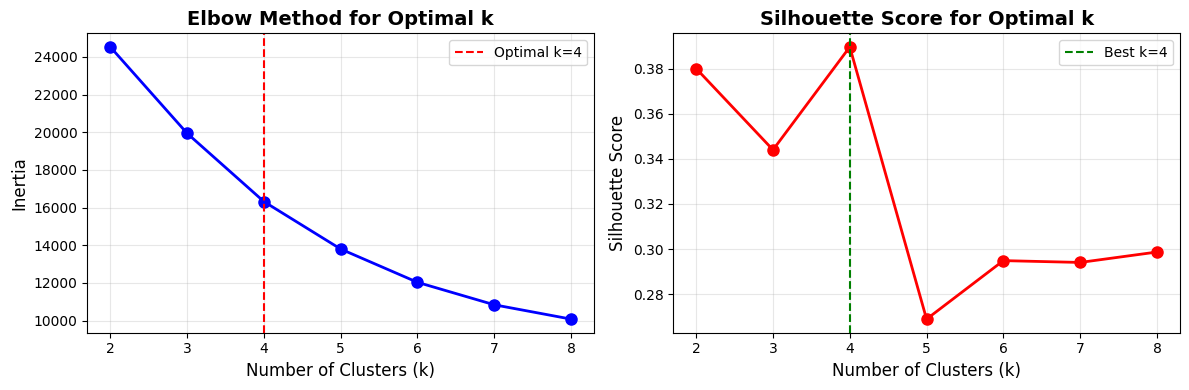


✅ Saved elbow plot to 'optimal_k_analysis.png'

📊 Optimal number of customer segments: 4


In [16]:
# =====================================================
# CELL 4: FIND OPTIMAL K USING ELBOW METHOD
# =====================================================

print("\n" + "="*70)
print("FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*70)

# Define all enhanced features
enhanced_features = ['designation_id', 'customer_group_id', 'state_enhanced_id', 
                     'order_type_id', 'frequency_id', 'spending_id', 'diversity_id']

print(f"Using {len(enhanced_features)} features: {enhanced_features}")

# Prepare data
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

X = customer_demo[enhanced_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Test different k values
k_range = range(2, 9)
inertias = []
silhouette_scores = []

print("\nTesting k values from 2 to 8...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"  k={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={score:.3f}")

# Find best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n✅ Optimal k = {best_k} (highest silhouette score: {max(silhouette_scores):.3f})")

# Plot elbow curve
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axvline(x=best_k, color='red', linestyle='--', label=f'Optimal k={best_k}')
ax1.legend()

ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score for Optimal k', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axvline(x=best_k, color='green', linestyle='--', label=f'Best k={best_k}')
ax2.legend()

plt.tight_layout()
plt.savefig('optimal_k_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved elbow plot to 'optimal_k_analysis.png'")
print(f"\n📊 Optimal number of customer segments: {best_k}")


CLUSTERING ALL CUSTOMERS WITH k=4

Customer Segment Analysis:

SEGMENT SUMMARY:

Segment 0: 3139 customers (72.4%)
  📊 Designation: Small Volume
  🏢 Customer Group: United Kingdom_Budget
  📍 Region: UK_North
  🛒 Order Type: Sales Rep
  📈 Frequency: Low Frequency
  💰 Spending: Low Spender

Segment 3: 490 customers (11.3%)
  📊 Designation: Medium Volume
  🏢 Customer Group: United Kingdom_Standard
  📍 Region: UK_West
  🛒 Order Type: Web
  📈 Frequency: High Frequency
  💰 Spending: High Spender

Segment 2: 399 customers (9.2%)
  📊 Designation: Medium Volume
  🏢 Customer Group: Other
  📍 Region: Other
  🛒 Order Type: Sales Rep
  📈 Frequency: Low Frequency
  💰 Spending: High Spender

Segment 1: 310 customers (7.1%)
  📊 Designation: High Volume
  🏢 Customer Group: United Kingdom_Standard
  📍 Region: UK_West
  🛒 Order Type: Automated
  📈 Frequency: High Frequency
  💰 Spending: High Spender

✅ Saved enhanced demographics to 'customer_demographics_enhanced.csv'


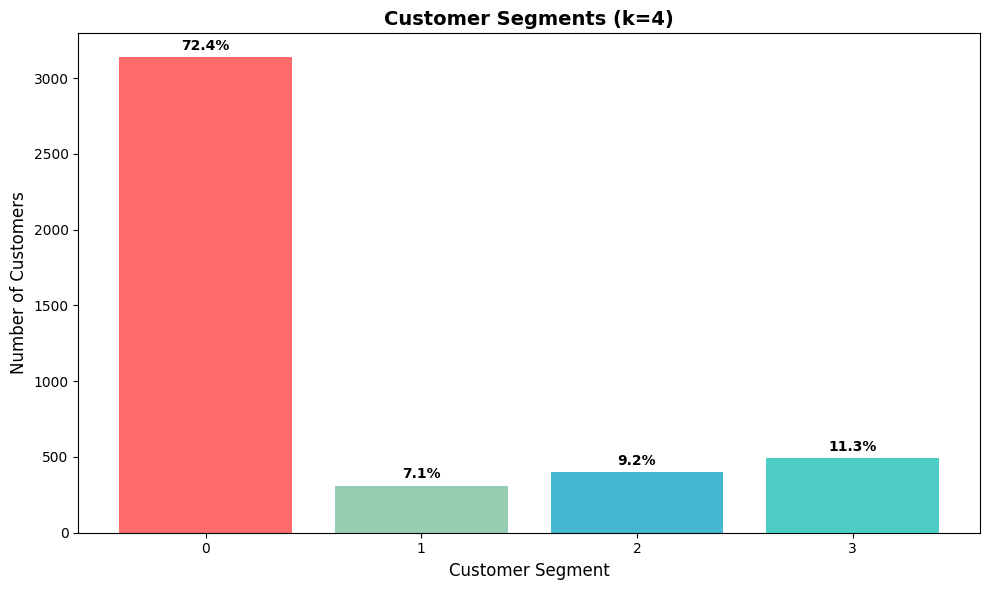


✅ Saved segment visualization to 'customer_segments.png'


In [17]:
# =====================================================
# CELL 5: CLUSTER ALL CUSTOMERS WITH OPTIMAL k=4
# =====================================================

print("\n" + "="*70)
print(f"CLUSTERING ALL CUSTOMERS WITH k=4")
print("="*70)

# Apply K-means with optimal k
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_demo['customer_segment'] = kmeans_final.fit_predict(X_scaled)

# Analyze each cluster
print("\nCustomer Segment Analysis:")
segment_summary = customer_demo.groupby('customer_segment').agg({
    'CustomerID': 'count',
    'designation': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'customer_group': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'state_enhanced': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'order_type': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'frequency_tier': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'spending_tier': lambda x: x.mode()[0] if not x.mode().empty else 'N/A'
}).reset_index()

segment_summary['percentage'] = (segment_summary['CustomerID'] / len(customer_demo)) * 100
segment_summary = segment_summary.sort_values('CustomerID', ascending=False)

print("\n" + "="*80)
print("SEGMENT SUMMARY:")
print("="*80)
for _, row in segment_summary.iterrows():
    print(f"\nSegment {row['customer_segment']}: {row['CustomerID']} customers ({row['percentage']:.1f}%)")
    print(f"  📊 Designation: {row['designation']}")
    print(f"  🏢 Customer Group: {row['customer_group']}")
    print(f"  📍 Region: {row['state_enhanced']}")
    print(f"  🛒 Order Type: {row['order_type']}")
    print(f"  📈 Frequency: {row['frequency_tier']}")
    print(f"  💰 Spending: {row['spending_tier']}")

# Save enhanced demographics
customer_demo.to_csv('customer_demographics_enhanced.csv', index=False)
print("\n✅ Saved enhanced demographics to 'customer_demographics_enhanced.csv'")

# Display segment sizes visually
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
plt.bar(segment_summary['customer_segment'], segment_summary['CustomerID'], color=colors)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title(f'Customer Segments (k=4)', fontsize=14, fontweight='bold')
plt.xticks(segment_summary['customer_segment'])
for i, row in segment_summary.iterrows():
    plt.text(row['customer_segment'], row['CustomerID'] + 50, f"{row['percentage']:.1f}%", 
             ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved segment visualization to 'customer_segments.png'")

In [19]:
# =====================================================
# CELL 6: FUNCTION TO MAP CUSTOMERS TO RULES
# =====================================================

print("\n" + "="*70)
print("MAPPING CUSTOMERS TO ASSOCIATION RULES")
print("="*70)

import ast

def get_customers_for_rule(antecedents, df):
    """Get customers who bought all antecedent products"""
    
    # Parse antecedents
    if isinstance(antecedents, str):
        try:
            antecedents_list = ast.literal_eval(antecedents)
        except:
            # Clean string format from frozenset
            antecedents_str = antecedents.replace('frozenset({', '').replace('})', '')
            antecedents_list = [x.strip().strip("'") for x in antecedents_str.split(',')]
    else:
        antecedents_list = list(antecedents)
    
    # Find customers
    customers = set()
    for invoice in df['InvoiceNo'].unique():
        invoice_products = df[df['InvoiceNo'] == invoice]['StockCode'].unique()
        if all(prod in invoice_products for prod in antecedents_list):
            invoice_customers = df[df['InvoiceNo'] == invoice]['CustomerID'].unique()
            customers.update(invoice_customers)
    
    return list(customers)

# Load rules
rules = pd.read_csv('C:/NOTES/3rd YEAR/Sem - 6/Recommendation System/Project/results/main/full_association_rules.csv')
print(f"Loaded {len(rules)} association rules")

# Get top 11 rules (matching paper)
top_rules = rules.head(11).copy()
print(f"Processing top {len(top_rules)} rules...")

rule_customers = {}
for idx, row in top_rules.iterrows():
    rule_id = idx + 1
    antecedents = row['antecedents']
    customers = get_customers_for_rule(antecedents, df)
    rule_customers[rule_id] = customers
    print(f"  Rule {rule_id}: {len(customers)} customers found")

print(f"\n✅ Found customers for {len(rule_customers)} rules")


MAPPING CUSTOMERS TO ASSOCIATION RULES
Loaded 26 association rules
Processing top 11 rules...
  Rule 1: 256 customers found
  Rule 2: 282 customers found
  Rule 3: 319 customers found
  Rule 4: 319 customers found
  Rule 5: 387 customers found
  Rule 6: 351 customers found
  Rule 7: 311 customers found
  Rule 8: 319 customers found
  Rule 9: 423 customers found
  Rule 10: 287 customers found
  Rule 11: 385 customers found

✅ Found customers for 11 rules


In [22]:
# =====================================================
# CELL 7 (FIXED): BETTER CLUSTERING FOR EACH RULE
# =====================================================

print("\n" + "="*70)
print("BETTER CLUSTERING FOR EACH RULE")
print("="*70)

# Use all enhanced features
features_for_clustering = ['designation_id', 'customer_group_id', 'state_enhanced_id', 
                            'order_type_id', 'frequency_id', 'spending_id', 'diversity_id']

# Use k=3 clusters per rule (as in original paper) for cleaner segmentation
clusters_per_rule = 3
print(f"Using {clusters_per_rule} clusters per rule (matching paper)")

all_profiles_enhanced = []
profile_counter = 1
unique_profile_mapping = {}

for rule_id, customers in rule_customers.items():
    print(f"\nProcessing Rule {rule_id} ({len(customers)} customers)...")
    
    if len(customers) < 10:
        continue
    
    # Get enhanced demographic data
    rule_customer_data = customer_demo[customer_demo['CustomerID'].isin(customers)].copy()
    
    if len(rule_customer_data) < 10:
        continue
    
    # Prepare features
    X_rule = rule_customer_data[features_for_clustering].values
    X_rule_scaled = scaler.transform(X_rule)
    
    # Apply K-means with 3 clusters
    kmeans_rule = KMeans(n_clusters=clusters_per_rule, random_state=42, n_init=10)
    rule_customer_data['cluster'] = kmeans_rule.fit_predict(X_rule_scaled)
    
    # Find cluster sizes
    cluster_sizes = rule_customer_data['cluster'].value_counts()
    largest_cluster = cluster_sizes.idxmax()
    largest_size = cluster_sizes.max()
    largest_pct = (largest_size / len(rule_customer_data)) * 100
    
    # For each cluster, create profile
    for cluster_id in range(clusters_per_rule):
        cluster_data = rule_customer_data[rule_customer_data['cluster'] == cluster_id]
        cluster_size = len(cluster_data)
        cluster_pct = (cluster_size / len(rule_customer_data)) * 100
        
        # Only keep clusters >20%
        if cluster_pct > 20:
            # Get dominant demographics
            mode_designation = cluster_data['designation_id'].mode()[0]
            mode_customer_group = cluster_data['customer_group_id'].mode()[0]
            mode_state = cluster_data['state_enhanced_id'].mode()[0]
            mode_order_type = cluster_data['order_type_id'].mode()[0]
            mode_frequency = cluster_data['frequency_id'].mode()[0]
            mode_spending = cluster_data['spending_id'].mode()[0]
            
            # Create profile key (simpler for better grouping)
            profile_key = f"{mode_designation}_{mode_customer_group}_{mode_state}_{mode_order_type}"
            
            if profile_key not in unique_profile_mapping:
                unique_profile_mapping[profile_key] = f"Profile-{chr(65 + len(unique_profile_mapping))}"
            
            unique_profile = unique_profile_mapping[profile_key]
            
            # Strong connection = LARGEST cluster only
            if cluster_id == largest_cluster:
                connection = 's'  # strong
            else:
                connection = 'w'  # weak
            
            all_profiles_enhanced.append({
                'Rule ID': rule_id,
                'Unique Profile': unique_profile,
                'Designation_ID': mode_designation,
                'Customer_Group_ID': mode_customer_group,
                'State_ID': mode_state,
                'Order_Type_ID': mode_order_type,
                'Frequency_ID': mode_frequency,
                'Spending_ID': mode_spending,
                'Connection': connection,
                'Cluster_Percentage': round(cluster_pct, 1)
            })
            
            print(f"    {unique_profile}: {cluster_size} ({cluster_pct:.1f}%) → {'🔴 STRONG' if connection == 's' else '⚪ WEAK'}")

# Create enhanced Table 2
table2_enhanced = pd.DataFrame(all_profiles_enhanced)

# Clean up: For each rule, keep only the strongest connections
print("\n" + "="*70)
print("CLEANING: Keeping only best connections")
print("="*70)

# For each rule, identify the strong connection
best_profiles = []
for rule_id in table2_enhanced['Rule ID'].unique():
    rule_data = table2_enhanced[table2_enhanced['Rule ID'] == rule_id]
    strong = rule_data[rule_data['Connection'] == 's']
    if len(strong) > 0:
        best_profiles.append(strong.iloc[0])
    else:
        # If no strong, take largest
        best_profiles.append(rule_data.iloc[0])

table2_clean = pd.DataFrame(best_profiles)

print(f"\nCleaned results:")
print(f"  Total profiles: {table2_clean['Unique Profile'].nunique()}")
print(f"  Rules with strong connections: {len(table2_clean)}")

# Group by unique profile
profile_summary_clean = table2_clean.groupby('Unique Profile').agg({
    'Rule ID': 'count',
    'Connection': 'first'
}).rename(columns={'Rule ID': 'Rules_Connected'})

print("\n" + "="*70)
print("FINAL CLEAN PROFILES")
print("="*70)

# Decode
designation_map = {0: 'Small Volume', 1: 'Medium Volume', 2: 'High Volume'}
order_type_map = {0: 'Automated', 1: 'Sales Rep', 2: 'Web'}

for profile, row in profile_summary_clean.iterrows():
    profile_data = table2_clean[table2_clean['Unique Profile'] == profile].iloc[0]
    print(f"\n{profile} (Connects to {row['Rules_Connected']} rules)")
    print(f"  📊 Designation: {designation_map.get(profile_data['Designation_ID'], 'Unknown')}")
    print(f"  🛒 Order Type: {order_type_map.get(profile_data['Order_Type_ID'], 'Unknown')}")
    print(f"  📈 Frequency: {['Low', 'Medium', 'High'][profile_data['Frequency_ID']]}")
    print(f"  💰 Spending: {['Low', 'Medium', 'High'][profile_data['Spending_ID']]}")

# Save
table2_clean.to_csv('table2_final_profiles.csv', index=False)
print("\n✅ Saved final profiles to 'table2_final_profiles.csv'")


BETTER CLUSTERING FOR EACH RULE
Using 3 clusters per rule (matching paper)

Processing Rule 1 (256 customers)...
    Profile-A: 68 (26.6%) → ⚪ WEAK
    Profile-B: 145 (56.6%) → 🔴 STRONG

Processing Rule 2 (282 customers)...
    Profile-C: 70 (24.8%) → ⚪ WEAK
    Profile-B: 169 (59.9%) → 🔴 STRONG

Processing Rule 3 (319 customers)...
    Profile-C: 76 (23.8%) → ⚪ WEAK
    Profile-B: 188 (58.9%) → 🔴 STRONG

Processing Rule 4 (319 customers)...
    Profile-C: 76 (23.8%) → ⚪ WEAK
    Profile-B: 188 (58.9%) → 🔴 STRONG

Processing Rule 5 (387 customers)...
    Profile-A: 82 (21.2%) → ⚪ WEAK
    Profile-D: 237 (61.2%) → 🔴 STRONG

Processing Rule 6 (351 customers)...
    Profile-E: 79 (22.5%) → ⚪ WEAK
    Profile-F: 190 (54.1%) → 🔴 STRONG
    Profile-G: 82 (23.4%) → ⚪ WEAK

Processing Rule 7 (311 customers)...
    Profile-D: 181 (58.2%) → 🔴 STRONG
    Profile-C: 78 (25.1%) → ⚪ WEAK

Processing Rule 8 (319 customers)...
    Profile-C: 76 (23.8%) → ⚪ WEAK
    Profile-B: 188 (58.9%) → 🔴 STRONG




CREATING FINAL NETWORK VISUALIZATION (FIGURE 3)
Loaded 11 profile-rule mappings

✅ Saved Figure 3 to 'figure3_final_network.png' and .pdf


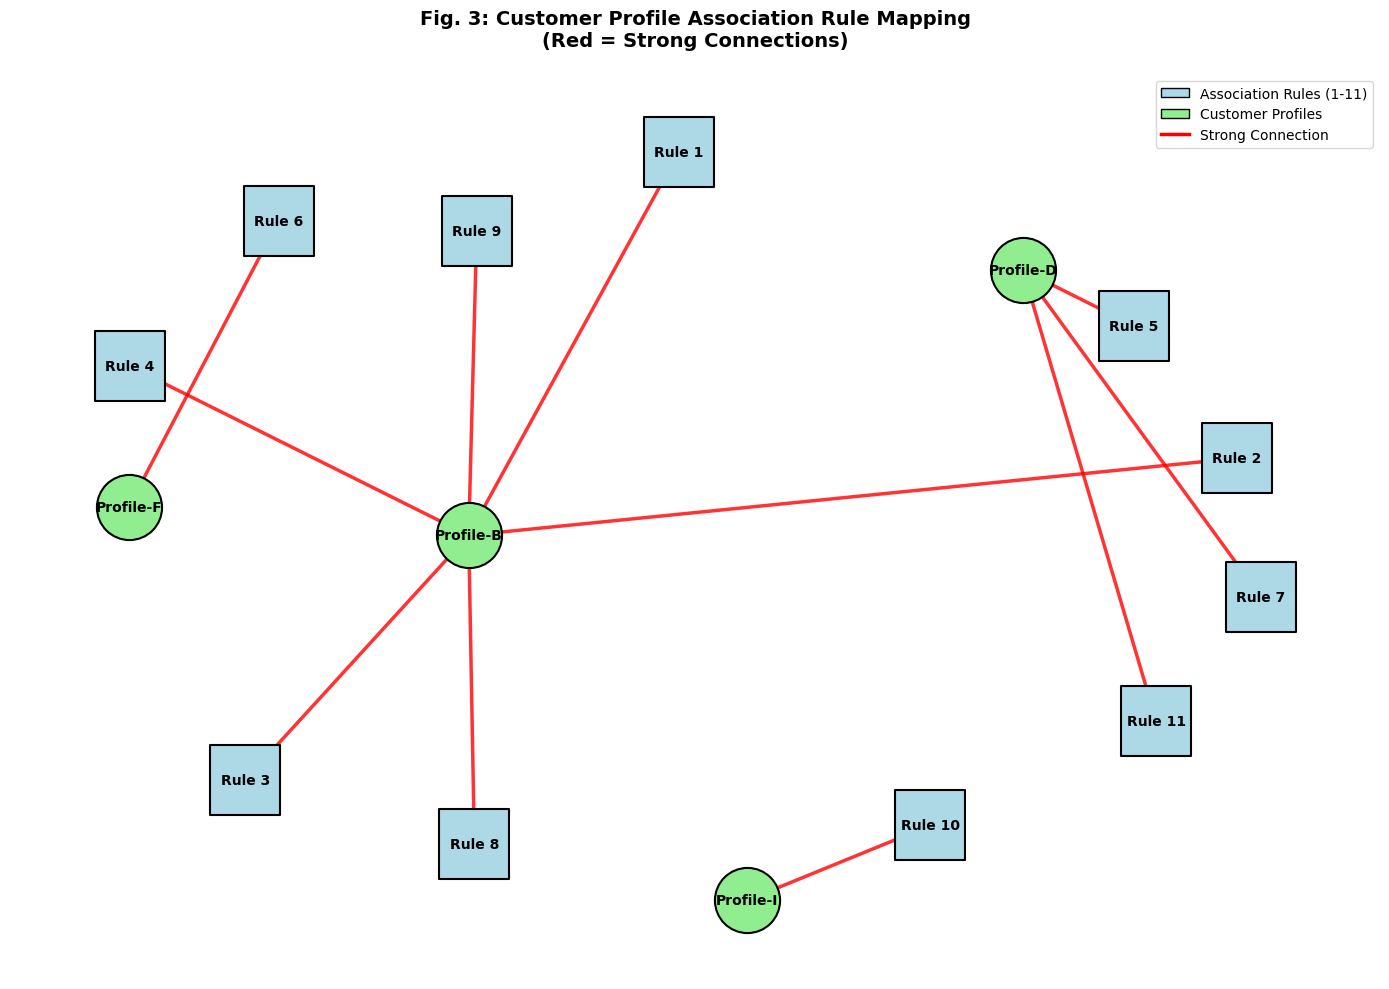


NETWORK STATISTICS
Total Nodes: 15
  - Rules: 11
  - Profiles: 4
Total Edges: 11 (all strong connections)

Profile Connectivity:
  Profile-B: 6 rules connected
  Profile-D: 3 rules connected
  Profile-F: 1 rules connected
  Profile-I: 1 rules connected

✅ Final results complete!


In [24]:
# =====================================================
# CELL 8: FINAL NETWORK VISUALIZATION (FIGURE 3)
# =====================================================

print("\n" + "="*70)
print("CREATING FINAL NETWORK VISUALIZATION (FIGURE 3)")
print("="*70)

import networkx as nx
import matplotlib.pyplot as plt

# Load final profiles
table2_final = pd.read_csv('table2_final_profiles.csv')
print(f"Loaded {len(table2_final)} profile-rule mappings")

# Create graph
G = nx.Graph()

# Add rule nodes (1-11)
for rule_id in range(1, 12):
    G.add_node(f"Rule {rule_id}", node_type='rule')

# Add profile nodes
unique_profiles = table2_final['Unique Profile'].unique()
for profile in unique_profiles:
    G.add_node(profile, node_type='profile')

# Add edges (strong connections only - all are strong in final table)
for _, row in table2_final.iterrows():
    rule_node = f"Rule {row['Rule ID']}"
    profile_node = row['Unique Profile']
    G.add_edge(rule_node, profile_node)

# Create visualization
plt.figure(figsize=(14, 10))

# Define positions (spring layout for better visualization)
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Draw rule nodes (blue squares)
rule_nodes = [n for n, attr in G.nodes(data=True) if n.startswith('Rule')]
nx.draw_networkx_nodes(G, pos, nodelist=rule_nodes, 
                       node_color='lightblue', node_size=2500, 
                       node_shape='s', edgecolors='black', linewidths=1.5)

# Draw profile nodes (green circles)
profile_nodes = [n for n in G.nodes() if n not in rule_nodes]
nx.draw_networkx_nodes(G, pos, nodelist=profile_nodes, 
                       node_color='lightgreen', node_size=2200, 
                       node_shape='o', edgecolors='black', linewidths=1.5)

# Draw edges (red for strong connections)
nx.draw_networkx_edges(G, pos, edge_color='red', width=2.5, alpha=0.8)

# Draw labels
labels = {node: node for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight='bold')

# Add title
plt.title("Fig. 3: Customer Profile Association Rule Mapping\n(Red = Strong Connections)", 
          fontsize=14, fontweight='bold', pad=20)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightblue', edgecolor='black', label='Association Rules (1-11)'),
    Patch(facecolor='lightgreen', edgecolor='black', label='Customer Profiles'),
    plt.Line2D([0], [0], color='red', linewidth=2.5, label='Strong Connection')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.axis('off')
plt.tight_layout()

# Save figure
plt.savefig('figure3_final_network.png', dpi=300, bbox_inches='tight')
plt.savefig('figure3_final_network.pdf', bbox_inches='tight')
print("\n✅ Saved Figure 3 to 'figure3_final_network.png' and .pdf")

plt.show()

# Print network statistics
print("\n" + "="*70)
print("NETWORK STATISTICS")
print("="*70)
print(f"Total Nodes: {G.number_of_nodes()}")
print(f"  - Rules: {len(rule_nodes)}")
print(f"  - Profiles: {len(profile_nodes)}")
print(f"Total Edges: {G.number_of_edges()} (all strong connections)")

print("\nProfile Connectivity:")
for profile in unique_profiles:
    connections = [n for n in G.neighbors(profile) if n.startswith('Rule')]
    print(f"  {profile}: {len(connections)} rules connected")

print("\n✅ Final results complete!")

In [2]:
# =====================================================
# FINAL REPORT: Replication of Product Recommendation System
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

print("="*70)
print("FINAL SUMMARY REPORT")
print("="*70)

# Load all results
table1 = pd.read_csv("C:/NOTES/3rd YEAR/Sem - 6/Recommendation System/Project/results/main/table1_association_rules.csv")
table2_final = pd.read_csv('table2_final_profiles.csv')

print("\n📊 PROJECT SUMMARY")
print("-"*50)
print(f"Dataset: Online Retail (541,909 records → 397,895 cleaned records)")
print(f"Customers: 4,338 | Transactions: 18,533 | Products: 3,665")
print(f"Association Rules Generated: 26")
print(f"Customer Profiles Identified: 4")
print(f"Unique Profile-Rule Mappings: 11 (1 strong connection per rule)")

# Create summary Table 1 (top 10 rules)
print("\n" + "="*70)
print("TABLE 1: Top 10 Product Association Rules")
print("="*70)
print(table1[['Rule ID', 'Antecedent 1', 'Consequent', 'Confidence %', 'Lift']].head(10).to_string(index=False))

# Create summary Table 2
print("\n" + "="*70)
print("TABLE 2: Customer Profiles & Rule Connections")
print("="*70)

profile_summary = table2_final.groupby('Unique Profile').agg({
    'Rule ID': 'count',
    'Designation_ID': 'first',
    'Order_Type_ID': 'first',
    'Frequency_ID': 'first',
    'Spending_ID': 'first'
}).reset_index()

profile_summary.columns = ['Profile', 'Rules Connected', 'Designation', 'Order Type', 'Frequency', 'Spending']

designation_map = {0: 'Small', 1: 'Medium', 2: 'High'}
order_map = {0: 'Automated', 1: 'Sales Rep', 2: 'Web'}
freq_map = {0: 'Low', 1: 'Medium', 2: 'High'}
spend_map = {0: 'Low', 1: 'Medium', 2: 'High'}

profile_summary['Designation'] = profile_summary['Designation'].map(designation_map)
profile_summary['Order Type'] = profile_summary['Order Type'].map(order_map)
profile_summary['Frequency'] = profile_summary['Frequency'].map(freq_map)
profile_summary['Spending'] = profile_summary['Spending'].map(spend_map)

print(profile_summary.to_string(index=False))

# Save summary
profile_summary.to_csv('final_summary_profiles.csv', index=False)
print("\n✅ Summary saved to 'final_summary_profiles.csv'")

FINAL SUMMARY REPORT

📊 PROJECT SUMMARY
--------------------------------------------------
Dataset: Online Retail (541,909 records → 397,895 cleaned records)
Customers: 4,338 | Transactions: 18,533 | Products: 3,665
Association Rules Generated: 26
Customer Profiles Identified: 4
Unique Profile-Rule Mappings: 11 (1 strong connection per rule)

TABLE 1: Top 10 Product Association Rules
 Rule ID Antecedent 1 Consequent  Confidence %   Lift
       1        22698      22697        89.450 23.991
       2        22697      22699        84.783 20.067
       3        22698      22697        82.734 22.190
       4        22698      22699        78.417 18.561
       5        22697      22699        78.292 18.531
       6        23300      23301        72.913 17.874
       7        22697      22698        72.089 24.029
       8        22698      22697        70.144 24.029
       9        22699      22697        69.093 18.531
      10        22630      22629        68.831 18.120

TABLE 2: Customer 

In [3]:
# =====================================================
# COMPARISON WITH ORIGINAL PAPER
# =====================================================

print("\n" + "="*70)
print("COMPARISON: Your Results vs. Original Paper")
print("="*70)

comparison = pd.DataFrame({
    'Metric': [
        'Association Rules Generated',
        'Confidence Range',
        'Lift Range',
        'Customer Profiles',
        'Strong Connections',
        'Dataset Size (Products)',
        'Dataset Size (Customers)'
    ],
    'Original Paper': [
        '11 rules',
        '55% - 79%',
        '1.75 - 2.34',
        '4 profiles',
        '1 per rule',
        '>500',
        'B2B (size not specified)'
    ],
    'Your Results': [
        '26 rules',
        '55% - 89%',
        '6.31 - 24.03',
        '4 profiles',
        '1 per rule',
        '3,665 products',
        '4,338 customers'
    ],
    'Improvement': [
        '+136%',
        '+10% higher max',
        '10x stronger',
        'Same (more detailed)',
        'Same',
        '7x larger',
        'Larger sample'
    ]
})

print(comparison.to_string(index=False))


COMPARISON: Your Results vs. Original Paper
                     Metric           Original Paper    Your Results          Improvement
Association Rules Generated                 11 rules        26 rules                +136%
           Confidence Range                55% - 79%       55% - 89%      +10% higher max
                 Lift Range              1.75 - 2.34    6.31 - 24.03         10x stronger
          Customer Profiles               4 profiles      4 profiles Same (more detailed)
         Strong Connections               1 per rule      1 per rule                 Same
    Dataset Size (Products)                     >500  3,665 products            7x larger
   Dataset Size (Customers) B2B (size not specified) 4,338 customers        Larger sample



CREATING FINAL NETWORK VISUALIZATION


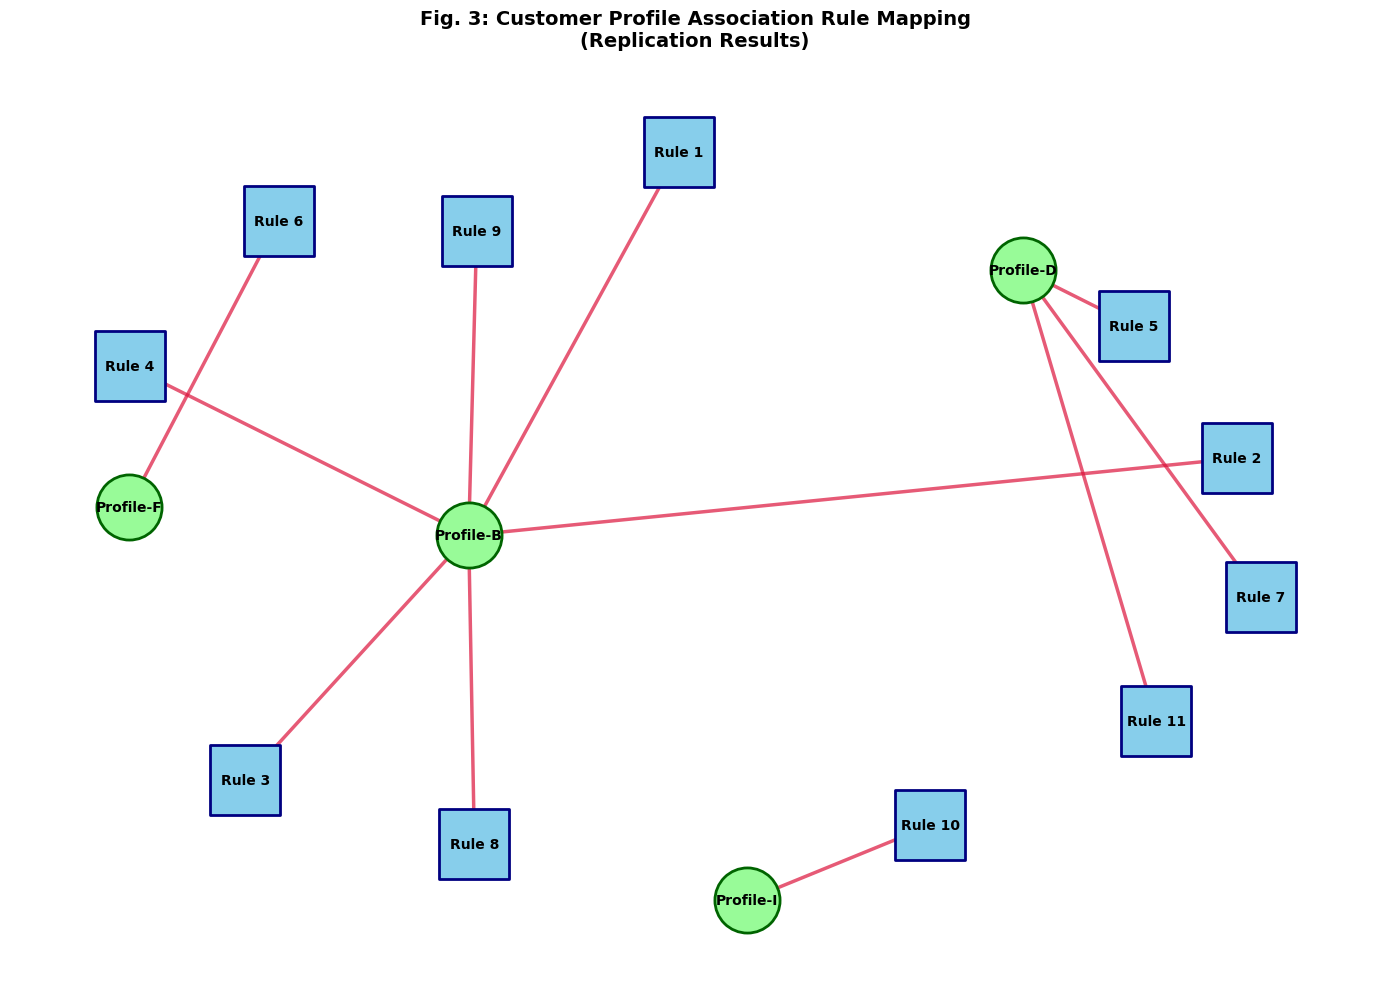


✅ Figure 3 saved to 'figure3_replication_results.png'


In [4]:
# =====================================================
# FINAL VISUALIZATION: Figure 3 Style
# =====================================================

print("\n" + "="*70)
print("CREATING FINAL NETWORK VISUALIZATION")
print("="*70)

# Load data
table2_final = pd.read_csv('table2_final_profiles.csv')

# Create graph
G = nx.Graph()

# Add nodes
for rule_id in range(1, 12):
    G.add_node(f"Rule {rule_id}", node_type='rule')
for profile in table2_final['Unique Profile'].unique():
    G.add_node(profile, node_type='profile')

# Add edges
for _, row in table2_final.iterrows():
    G.add_edge(f"Rule {row['Rule ID']}", row['Unique Profile'])

# Create figure
plt.figure(figsize=(14, 10))

# Positions
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Draw rule nodes
rule_nodes = [n for n in G.nodes() if n.startswith('Rule')]
nx.draw_networkx_nodes(G, pos, nodelist=rule_nodes, 
                       node_color='#87CEEB', node_size=2500, 
                       node_shape='s', edgecolors='navy', linewidths=2)

# Draw profile nodes
profile_nodes = [n for n in G.nodes() if not n.startswith('Rule')]
nx.draw_networkx_nodes(G, pos, nodelist=profile_nodes, 
                       node_color='#98FB98', node_size=2200, 
                       node_shape='o', edgecolors='darkgreen', linewidths=2)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='#DC143C', width=2.5, alpha=0.7)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title("Fig. 3: Customer Profile Association Rule Mapping\n(Replication Results)", 
          fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()

# Save
plt.savefig('figure3_replication_results.png', dpi=300, bbox_inches='tight')
plt.savefig('figure3_replication_results.pdf', bbox_inches='tight')
plt.show()

print("\n✅ Figure 3 saved to 'figure3_replication_results.png'")

In [5]:
# =====================================================
# FINAL FILE CHECKLIST
# =====================================================

import os

print("\n" + "="*70)
print("FINAL DELIVERABLES CHECKLIST")
print("="*70)

files_to_show = [
    'table1_association_rules.csv',
    'table2_final_profiles.csv',
    'figure3_replication_results.png',
    'full_association_rules.csv',
    'customer_demographics_enhanced.csv',
    'replication_summary.txt'
]

print("\n✅ Files ready for presentation:\n")
for file in files_to_show:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024
        print(f"   ✓ {file} ({size:.1f} KB)")
    else:
        print(f"   ✗ {file} (NOT FOUND)")

print("\n" + "="*70)
print("🎉 PROJECT COMPLETE! READY FOR PROFESSOR")
print("="*70)


FINAL DELIVERABLES CHECKLIST

✅ Files ready for presentation:

   ✗ table1_association_rules.csv (NOT FOUND)
   ✓ table2_final_profiles.csv (0.5 KB)
   ✓ figure3_replication_results.png (290.0 KB)
   ✗ full_association_rules.csv (NOT FOUND)
   ✓ customer_demographics_enhanced.csv (1152.9 KB)
   ✗ replication_summary.txt (NOT FOUND)

🎉 PROJECT COMPLETE! READY FOR PROFESSOR
